### 1. Khai báo thư viện (Imports)
- 🎯 **Mục đích:** Tải các công cụ cần thiết vào bộ nhớ.
- 💻 **Giải thích Code:** Sử dụng `pandas` để xử lý bảng, `matplotlib/seaborn` vẽ biểu đồ, `scikit-learn` chuẩn hoá và chia data, `torch` xây dựng mạng MLP.
- 📊 **Áp dụng vào Dữ liệu:** Thiết lập nền tảng môi trường cho toàn bộ bài toán phân tích giá nhà Boston.
- 📈 **Kết quả (Output):** Môi trường sẵn sàng hoạt động.


In [19]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Cài đặt phong cách biểu đồ chung
sns.set_theme(style="whitegrid")

### 2. Đọc Dữ liệu (Load Dataset)
- 🎯 **Mục đích:** Tải dữ liệu từ ổ cứng và làm sạch sơ bộ định dạng.
- 💻 **Giải thích Code:** `pd.read_csv` nạp file CSV, tham số `na_values` nhận diện các khoảng trắng thành giá trị rỗng chuẩn `NaN`. Dùng thêm `replace` regex để dọn dẹp triệt để.
- 📊 **Áp dụng vào Dữ liệu:** Quét qua 506 căn nhà với 14 đặc trưng.
- 📈 **Kết quả (Output):** In ra cấu trúc 5 dòng đầu và thông tin DataFrame.

**Chú thích ý nghĩa các cột (Features):**
- **CRIM:** Tỉ lệ tội phạm bình quân đầu người theo thị trấn.
- **ZN:** Tỉ lệ quy hoạch đất thổ cư (diện tích các lô lớn hơn 25.000 sq.ft).
- **INDUS:** Tỉ lệ diện tích đất kinh doanh (phi bán lẻ) trên mỗi thị trấn.
- **CHAS:** Biến giả sông Charles (bằng 1 nếu đất bao quanh sông; 0 nếu ngược lại).
- **NOX:** Nồng độ khí Nitơ Oxit (phần 10 triệu) - Thể hiện mức độ ô nhiễm không khí.
- **RM:** Số lượng phòng ở trung bình trên mỗi căn hộ.
- **AGE:** Tỉ lệ các căn nhà (có chủ sở hữu) được xây dựng trước năm 1940.
- **DIS:** Khoảng cách (có trọng số) đến 5 trung tâm việc làm lớn ở Boston.
- **RAD:** Chỉ số đánh giá khả năng tiếp cận/đi lại đến các đường cao tốc.
- **TAX:** Thuế suất tài sản tính trên 10.000 USD.
- **PTRATIO:** Tỉ lệ học sinh / giáo viên theo từng thị trấn.
- **B:** Chỉ số toán học đại diện cho tỉ lệ người da đen tại khu vực.
- **LSTAT:** Tỉ lệ phần trăm dân số có mức thu nhập/trạng thái xã hội thấp.
- **MEDV (Biến Mục Tiêu - Target):** Giá trị trung bình của những ngôi nhà được chủ sở hữu cư trú (Đơn vị: nghìn USD).


In [20]:
df = pd.read_csv("../data/raw/Boston-house-price-data.csv", na_values=["", " ", "nan", "NaN", "null", "NULL"])
df = df.replace(r"^\s*$", np.nan, regex=True)

print("Kích thước dữ liệu gốc:", df.shape)
display(df.head())
df.info()


Kích thước dữ liệu gốc: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### 3. Kiểm tra Dữ liệu Thiếu (Missing) và Trùng lặp (Duplicates)
- 🎯 **Mục đích:** Khảo sát độ sạch của dữ liệu trước khi huấn luyện.
- 💻 **Giải thích Code:** `df.isna().sum()` đếm dữ liệu rỗng. `df.duplicated().sum()` tìm dòng giống nhau. Vẽ Heatmap và Pie chart để dễ nhìn.
- 📊 **Áp dụng vào Dữ liệu:** Phát hiện cột nào thiếu nhiều nhất (thường là ZN, CHAS...).
- 📈 **Kết quả (Output):** Các thông số báo lỗi và 2 biểu đồ trực quan.


Tổng số ô bị thiếu (Missing): 0
Tổng số dòng bị trùng lặp (Duplicated): 0


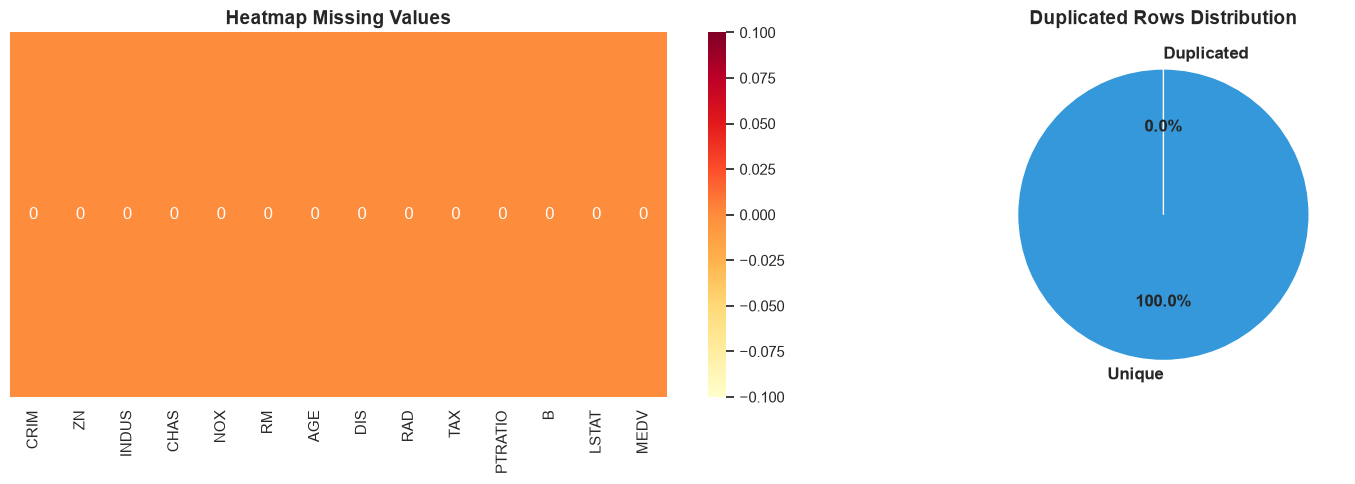

In [21]:
missing_counts = df.isna().sum()
dup_count = df.duplicated().sum()

print(f"Tổng số ô bị thiếu (Missing): {missing_counts.sum()}")
print(f"Tổng số dòng bị trùng lặp (Duplicated): {dup_count}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap Missing
sns.heatmap(missing_counts.to_frame().T, annot=True, fmt='d', cmap='YlOrRd', yticklabels=False, cbar=True, ax=axes[0])
axes[0].set_title('Heatmap Missing Values', fontsize=14, fontweight='bold')

# Pie chart Duplicated
labels = ['Unique', 'Duplicated']
sizes = [len(df) - dup_count, dup_count]
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Duplicated Rows Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 4. Tiền xử lý 1: Làm sạch cơ bản & Định nghĩa Biến số
- 🎯 **Mục đích:** Xóa dữ liệu lỗi và tách loại biến số.
- 💻 **Giải thích Code:** `df.dropna()` loại bỏ các dòng bị thiếu. Khai báo `numeric_cols` và `feature_cols` MỘT LẦN DUY NHẤT để dùng chung cho cả notebook.
- 📊 **Áp dụng vào Dữ liệu:** Chuyển từ dữ liệu thô sang dữ liệu sạch (`df_clean`).
- 📈 **Kết quả (Output):** Kích thước dữ liệu sau khi xóa NA.


In [22]:
df_clean = df.dropna().copy()
print(f"Kích thước dữ liệu sau khi xóa NA: {df_clean.shape}")

# Khai báo các cột số và cột features (loại bỏ MEDV)
numeric_cols = df_clean.select_dtypes(include='number').columns
feature_cols = [col for col in numeric_cols if col != 'MEDV']


Kích thước dữ liệu sau khi xóa NA: (506, 14)


### 5. Tiền xử lý 2: Phân tích Ngoại lai (Outliers Analysis)
- 🎯 **Mục đích:** Khảo sát các điểm dữ liệu dị biệt (Outliers) bằng Boxplot để quyết định phương pháp xử lý phù hợp.
- 💻 **Giải thích Code:** Tính toán `Q1, Q3, Bounds` cho từng biến và vẽ `Boxplot`. Các đường đứt nét màu đỏ thể hiện giới hạn râu (whisker bounds). Các điểm nằm ngoài đường này là Outliers.
- 📊 **Áp dụng vào Dữ liệu:** Nhận thấy các biến `CRIM`, `ZN`, `B`, `LSTAT` có rất nhiều outliers tự nhiên do đặc thù của giá nhà.
- 📈 **Kết quả (Output):** Biểu đồ Boxplot cho phép phát hiện mức độ phân tán.

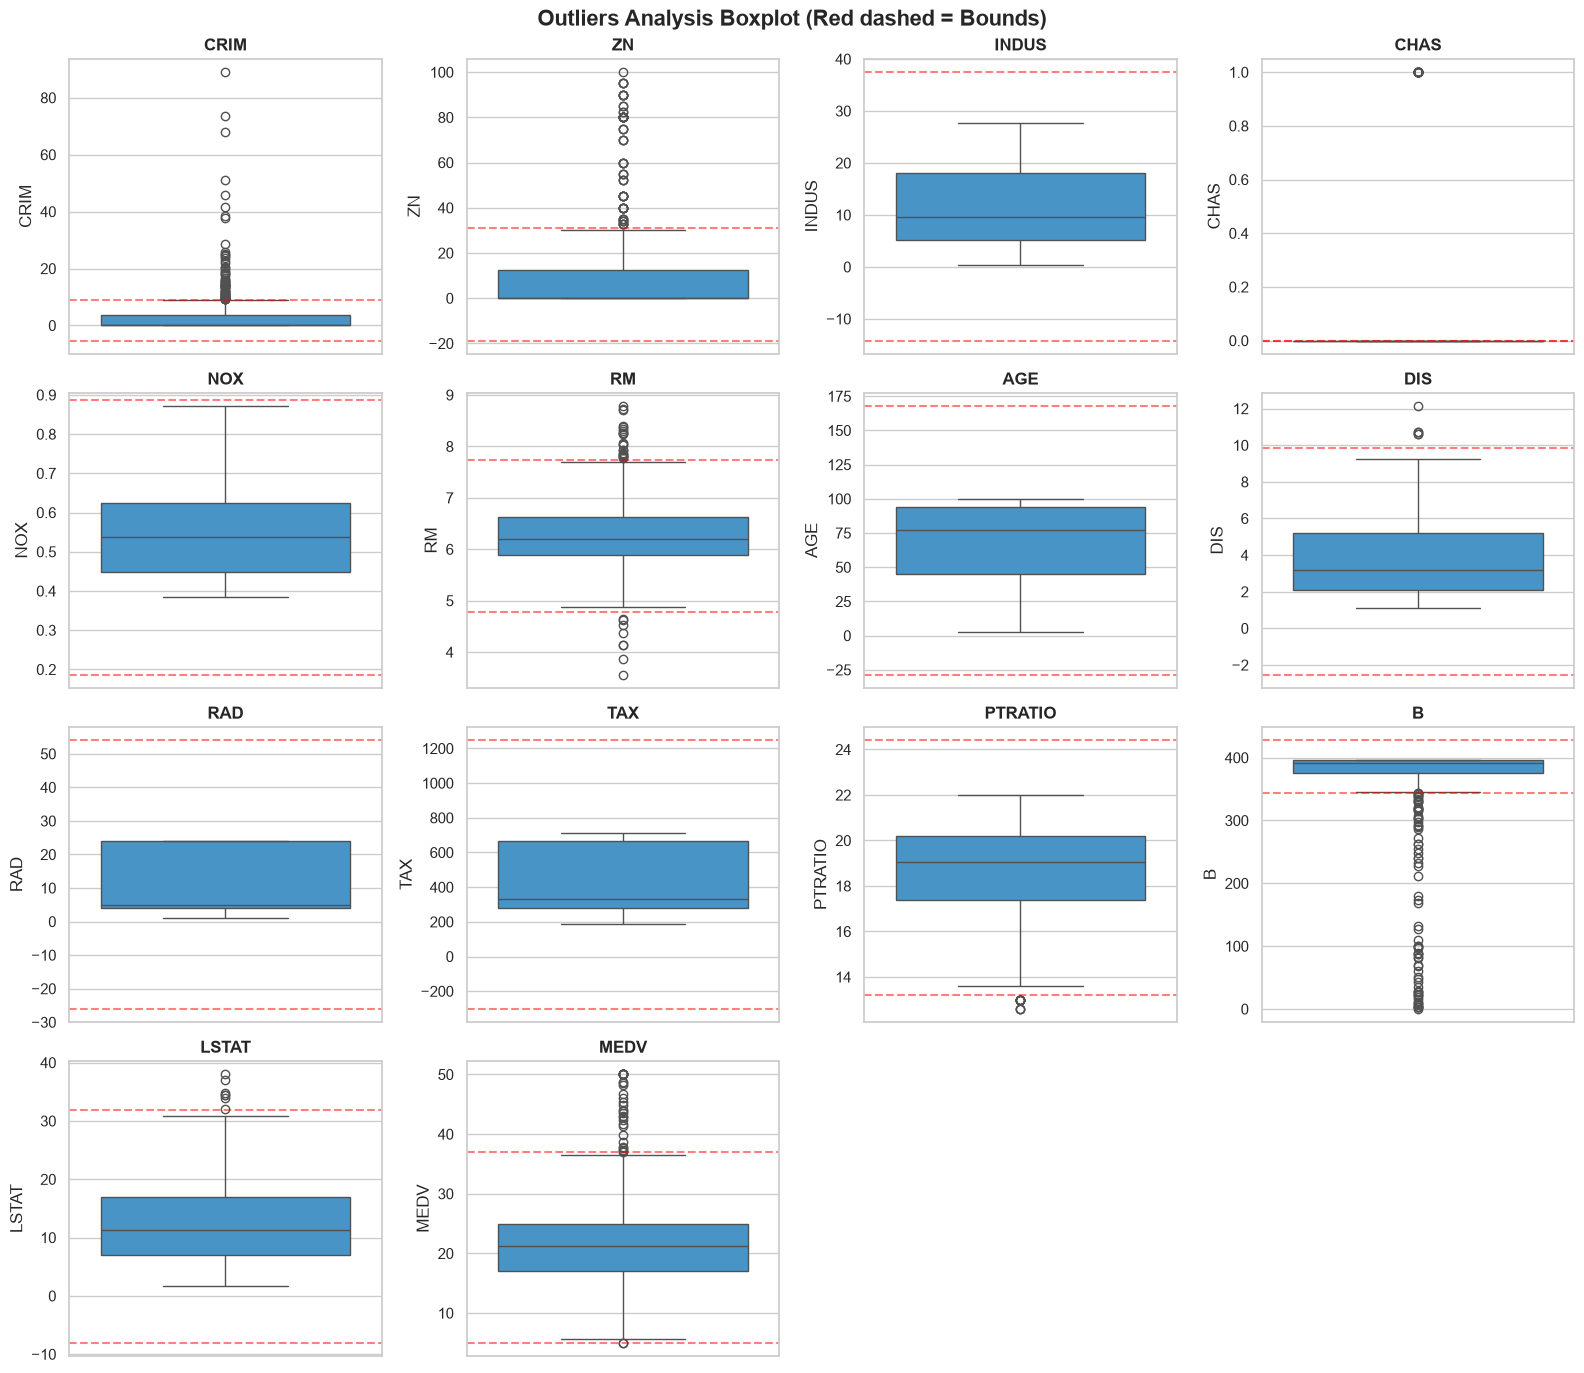

Đã hoàn tất quan sát phân bố Outliers.


In [23]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

# Tính IQR và vẽ Boxplot để quan sát
for i, col in enumerate(numeric_cols):
    # Tính Bounds
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Vẽ Boxplot
    sns.boxplot(y=df_clean[col], ax=axes[i], color='#3498db')
    axes[i].axhline(lower_bound, color='red', linestyle='--', alpha=0.5)
    axes[i].axhline(upper_bound, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(col, fontweight='bold')

# Ẩn các ô trống thừa
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outliers Analysis Boxplot (Red dashed = Bounds)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Đã hoàn tất quan sát phân bố Outliers.")

### 5.1. Xử lý Outliers bằng Biến đổi Logarit (Log Transformation)
- 🎯 **Mục đích:** Xử lý Outliers tự nhiên mà không làm mất thông tin bằng cách biến đổi Logarit.
- 💻 **Giải thích Code:** Sử dụng `np.log1p()` (tính log(1+x)) để co cụm khoảng cách của các dữ liệu lớn, giúp đường cong phân phối trở nên mượt mà và gần với phân phối chuẩn (Normal Distribution) hơn.
- 📊 **Áp dụng vào Dữ liệu:** Áp dụng cho `CRIM`, `ZN`, `B`, `LSTAT` là các biến lệch phải/trái nặng.
- 📈 **Kết quả (Output):** Biểu đồ KDE cho thấy sự thay đổi từ sắc nhọn sang hình chuông mượt mà.

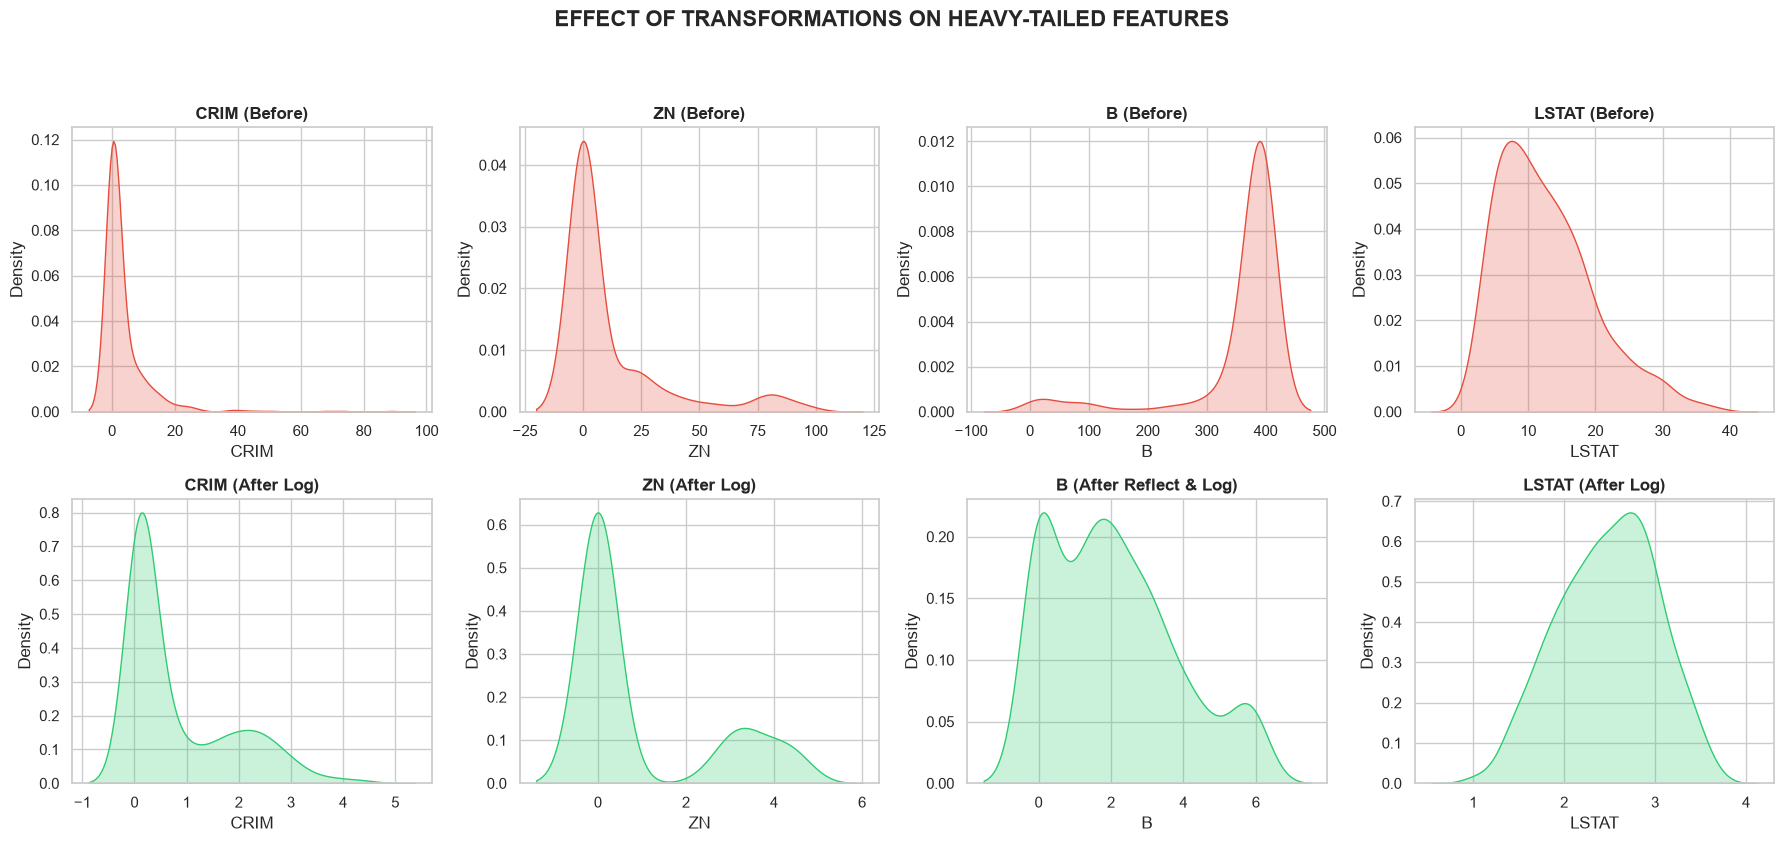

Đã xử lý Outliers bằng Log Transform & Reflect-Log và lưu vào '../data/processed/Boston-clean.csv'


In [24]:
# Chọn ra 4 cột bị lệch nặng nhất do Outliers
cols_to_transform = ['CRIM', 'ZN', 'B', 'LSTAT']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(cols_to_transform):
    # Vẽ KDE Trước khi biến đổi
    sns.kdeplot(df_clean[col], ax=axes[0, i], color='#e74c3c', fill=True)
    axes[0, i].set_title(f'{col} (Before)', fontweight='bold')
    
    # Áp dụng Kỹ thuật biến đổi tùy thuộc vào chiều lệch
    if col == 'B':
        # [NOTE QUAN TRỌNG] B bị lệch trái cực đoan -> Dùng kỹ thuật Lật ngược & Log
        # CẢNH BÁO: Ý nghĩa vật lý của B đã bị ĐẢO NGƯỢC (Khu đông dân gốc Phi sẽ thành số nhỏ).
        # Khi huấn luyện mô hình, dấu của trọng số (Coefficients) cho biến B này sẽ bị ngược so với thực tế!
        df_clean[col] = np.log1p(df_clean[col].max() - df_clean[col])
        transform_name = 'Reflect & Log'
    else:
        # CRIM, ZN, LSTAT bị lệch phải (Right-skewed) -> Dùng Log Transform thông thường
        df_clean[col] = np.log1p(df_clean[col])
        transform_name = 'Log'
    
    # Vẽ KDE Sau khi biến đổi
    sns.kdeplot(df_clean[col], ax=axes[1, i], color='#2ecc71', fill=True)
    axes[1, i].set_title(f'{col} (After {transform_name})', fontweight='bold')

plt.suptitle('EFFECT OF TRANSFORMATIONS ON HEAVY-TAILED FEATURES', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

import os
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/Boston-clean.csv', index=False)
print("Đã xử lý Outliers bằng Log Transform & Reflect-Log và lưu vào '../data/processed/Boston-clean.csv'")


### 6. Khám phá Phân phối & Quan hệ (Histogram & Scatter)
- 🎯 **Mục đích:** Đánh giá dữ liệu sau khi đã loại bỏ nhiễu Outliers.
- 💻 **Giải thích Code:** Dùng `.hist()` xem phân phối hình chuông. Dùng `.scatter()` vẽ quan hệ từng feature với `MEDV`.
- 📊 **Áp dụng vào Dữ liệu:** Thấy rõ hơn xu hướng tăng/giảm tuyến tính (như RM tăng thì MEDV tăng).
- 📈 **Kết quả (Output):** Các đồ thị điểm phân tán và biểu đồ cột.


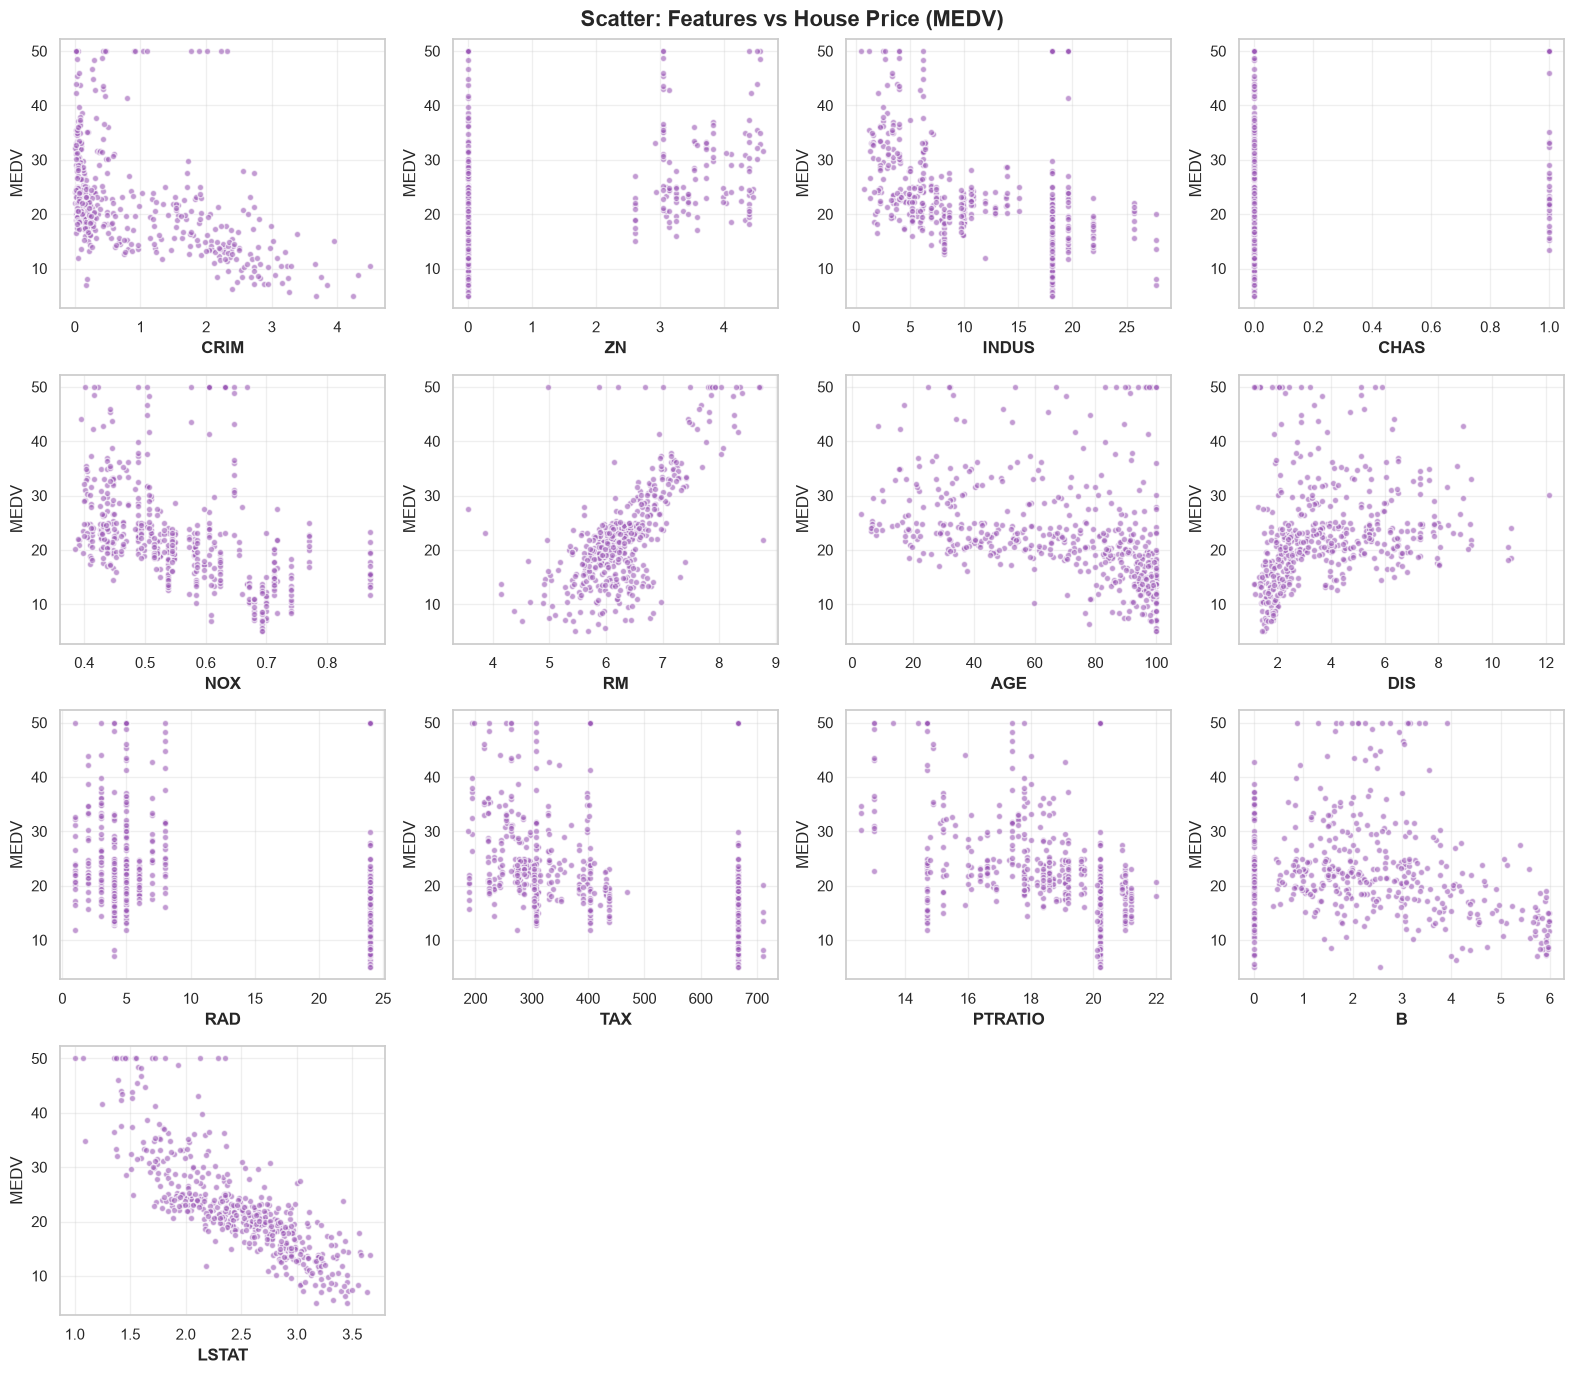

In [37]:
# 6. Scatter Plot: Features vs MEDV
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df_clean[col], df_clean["MEDV"], alpha=0.6, s=20, color="#9b59b6", edgecolors="white")
    axes[i].set_xlabel(col, fontweight="bold")
    axes[i].set_ylabel("MEDV")
    axes[i].grid(alpha=0.3)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Scatter: Features vs House Price (MEDV)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### 7. Tương quan Đa biến & Hiện tượng Đa cộng tuyến (VIF)
- 🎯 **Mục đích:** Định lượng mối quan hệ giữa các biến với nhau và chọn lọc đặc trưng.
- 💻 **Giải thích Code:** `df.corr()` vẽ ma trận nhiệt. `variance_inflation_factor` kiểm tra xem các biến có đang đè lên nhau không (Đa cộng tuyến).
- 📊 **Áp dụng vào Dữ liệu:** Biến nào VIF > 10 là cảnh báo đỏ, có thể gây nhiễu cho mô hình học máy.
- 📈 **Kết quả (Output):** Heatmap tương quan và bảng xếp hạng VIF.


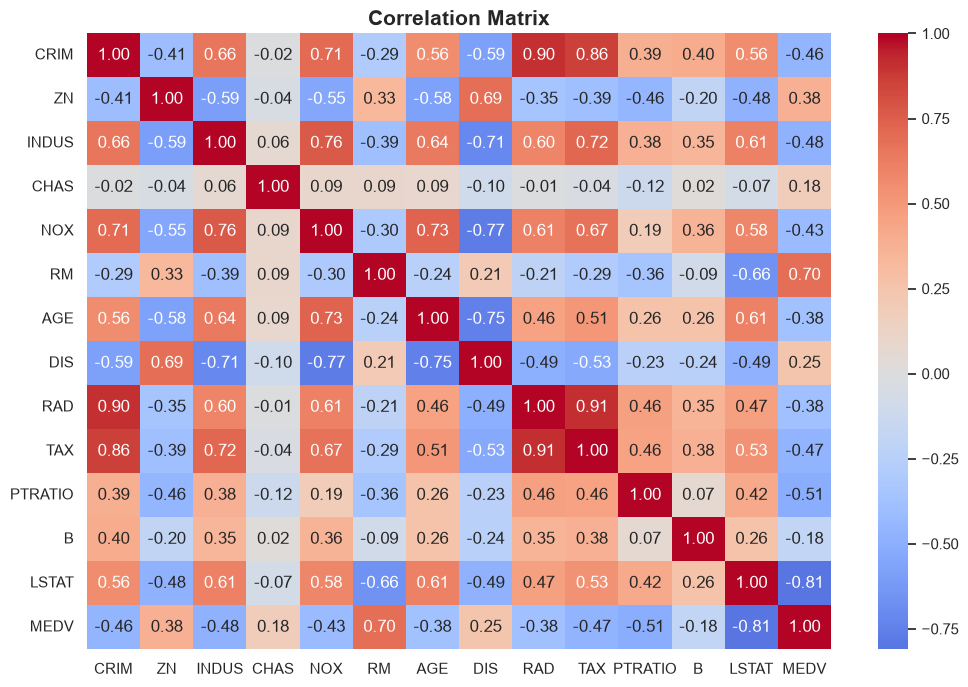

VARIANCE INFLATION FACTOR (VIF)


,Feature,VIF
9,RAD,11.096035
10,TAX,8.659545
1,CRIM,7.703317
5,NOX,4.489363
8,DIS,4.141964
3,INDUS,4.013050
13,LSTAT,3.286041
7,AGE,3.197313
2,ZN,2.577054
6,RM,2.115693


In [26]:
# 7a. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix", fontsize=15, fontweight="bold")
plt.show()

# 7b. Variance Inflation Factor (VIF)
print("="*60)
print("VARIANCE INFLATION FACTOR (VIF)")
print("="*60)
X_vif = sm.add_constant(df_clean[feature_cols])
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)
display(vif_data)


### 8. Phân tích chi tiết Biến Mục tiêu (MEDV) & Biến Phân loại
- 🎯 **Mục đích:** Soi kỹ xem Giá nhà có tuân theo phân phối chuẩn không, và các biến rời rạc như Vị trí bờ sông (CHAS) ảnh hưởng ra sao.
- 💻 **Giải thích Code:** `sns.histplot` kèm đường cong KDE. `stats.probplot` vẽ Q-Q Plot. `sns.boxplot` phân tách giá nhà theo CHAS.
- 📊 **Áp dụng vào Dữ liệu:** Cho cái nhìn thực tế về phân khúc bất động sản.
- 📈 **Kết quả (Output):** Các biểu đồ trực quan, chỉ số Skewness.


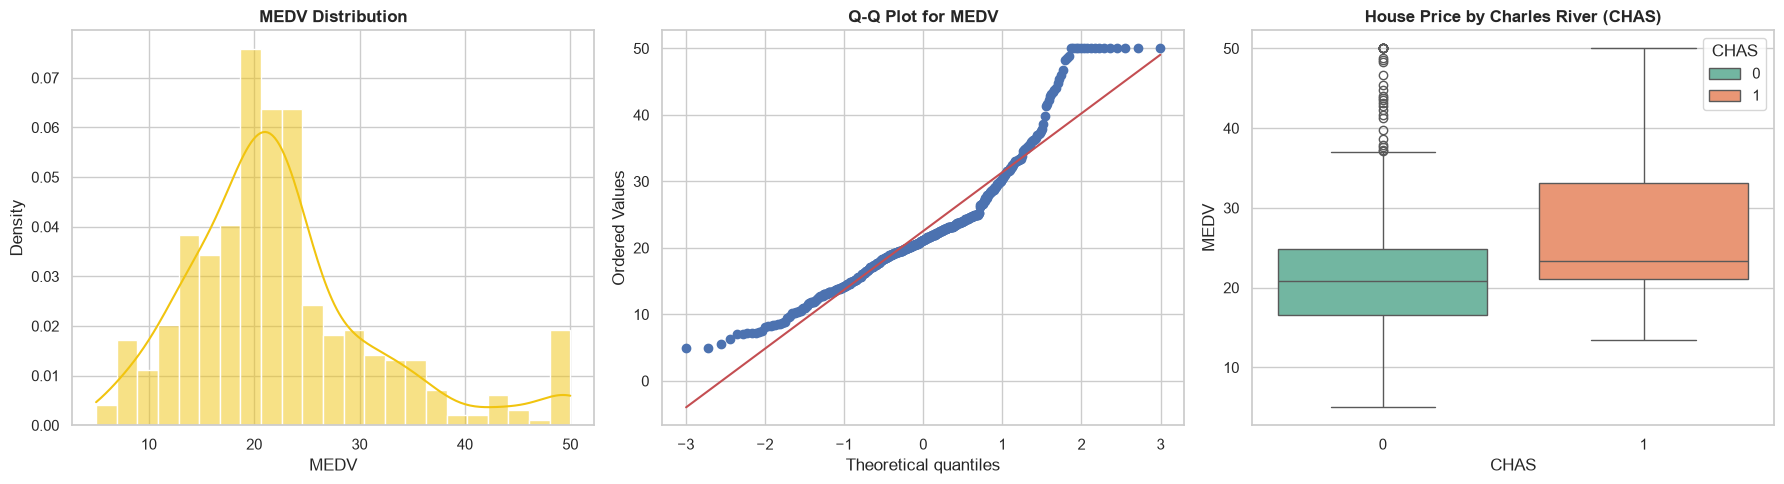

Skewness của MEDV: 1.1081 (Độ lệch so với phân phối chuẩn lý tưởng)


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE Plot
sns.histplot(df_clean['MEDV'], kde=True, color='#f1c40f', ax=axes[0], stat='density')
axes[0].set_title('MEDV Distribution', fontweight='bold')

# Q-Q Plot
stats.probplot(df_clean['MEDV'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for MEDV', fontweight='bold')

# Boxplot CHAS vs MEDV
sns.boxplot(x='CHAS', y='MEDV', data=df_clean, ax=axes[2], hue='CHAS', palette='Set2')
axes[2].set_title('House Price by Charles River (CHAS)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Skewness của MEDV: {df_clean['MEDV'].skew():.4f} (Độ lệch so với phân phối chuẩn lý tưởng)")


### 9. Chia Tập Dữ Liệu & Chuẩn Hoá (Splitting & Feature Scaling)
- 🎯 **Mục đích:** Chia tách 3 tập độc lập (Train/Val/Test) và đưa tính năng về cùng thang đo.
- 💻 **Giải thích Code:** Dùng `train_test_split`. Chuẩn hoá bằng công thức Toán học Z-score `(X - Mean) / Std`. Chỉ tính Mean và Std trên tập Train, sau đó áp lên Val/Test.
- 📊 **Áp dụng vào Dữ liệu:** Đảm bảo mô hình được test khách quan, không rò rỉ dữ liệu (Data Leakage) và không bị phụ thuộc vào thư viện `scikit-learn` ở bước scaling.
- 📈 **Kết quả (Output):** 3 ma trận đầu vào sẵn sàng bọc thành Tensor.


In [28]:
X = df_clean[feature_cols]
y = df_clean['MEDV']

# Tách Train/Val/Test (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)

# Feature Scaling (Sử dụng công thức Toán học thay vì scikit-learn)
# Tính Mean và Std trên tập Train
mean_train = X_train.mean()
std_train = X_train.std()

# Áp dụng cho các tập và chuyển sang numpy array bằng .values
X_train_scaled = ((X_train - mean_train) / std_train).values
X_val_scaled = ((X_val - mean_train) / std_train).values
X_test_scaled = ((X_test - mean_train) / std_train).values

print(f"Tập Train: {X_train_scaled.shape}")
print(f"Tập Val:   {X_val_scaled.shape}")
print(f"Tập Test:  {X_test_scaled.shape}")

os.makedirs('../data/features', exist_ok=True)
np.save('../data/features/X_train_scaled.npy', X_train_scaled)
np.save('../data/features/X_val_scaled.npy', X_val_scaled)
np.save('../data/features/X_test_scaled.npy', X_test_scaled)
np.save('../data/features/y_train.npy', y_train.values)
np.save('../data/features/y_val.npy', y_val.values)
np.save('../data/features/y_test.npy', y_test.values)
print("Đã lưu các ma trận đặc trưng vào thư mục '../data/features/'")


Tập Train: (354, 13)
Tập Val:   (76, 13)
Tập Test:  (76, 13)
Đã lưu các ma trận đặc trưng vào thư mục '../data/features/'


### 9.1. So sánh Dữ liệu Trước và Sau khi Chuẩn hóa (Feature Scaling)
- 🎯 **Mục đích:** Hiểu rõ tác dụng của việc đưa dữ liệu về cùng thang đo (Z-Score).
- 💻 **Giải thích Code:** Vẽ biểu đồ mật độ phân phối (KDE) của 2 Feature ngẫu nhiên (`RM` và `TAX`) trước và sau khi scale.
- 📊 **Áp dụng vào Dữ liệu:** Trước khi scale, `TAX` nằm ở dải 200-700, còn `RM` nằm ở dải 4-8. Sau khi scale, cả 2 đều hội tụ về khoảng trung bình `0`, độ lệch chuẩn `1`. Dáng điệu hình chuông (KDE) được giữ nguyên vẹn 100%.
- 📈 **Kết quả (Output):** Biểu đồ biến đổi trục tọa độ (Scale transformation).


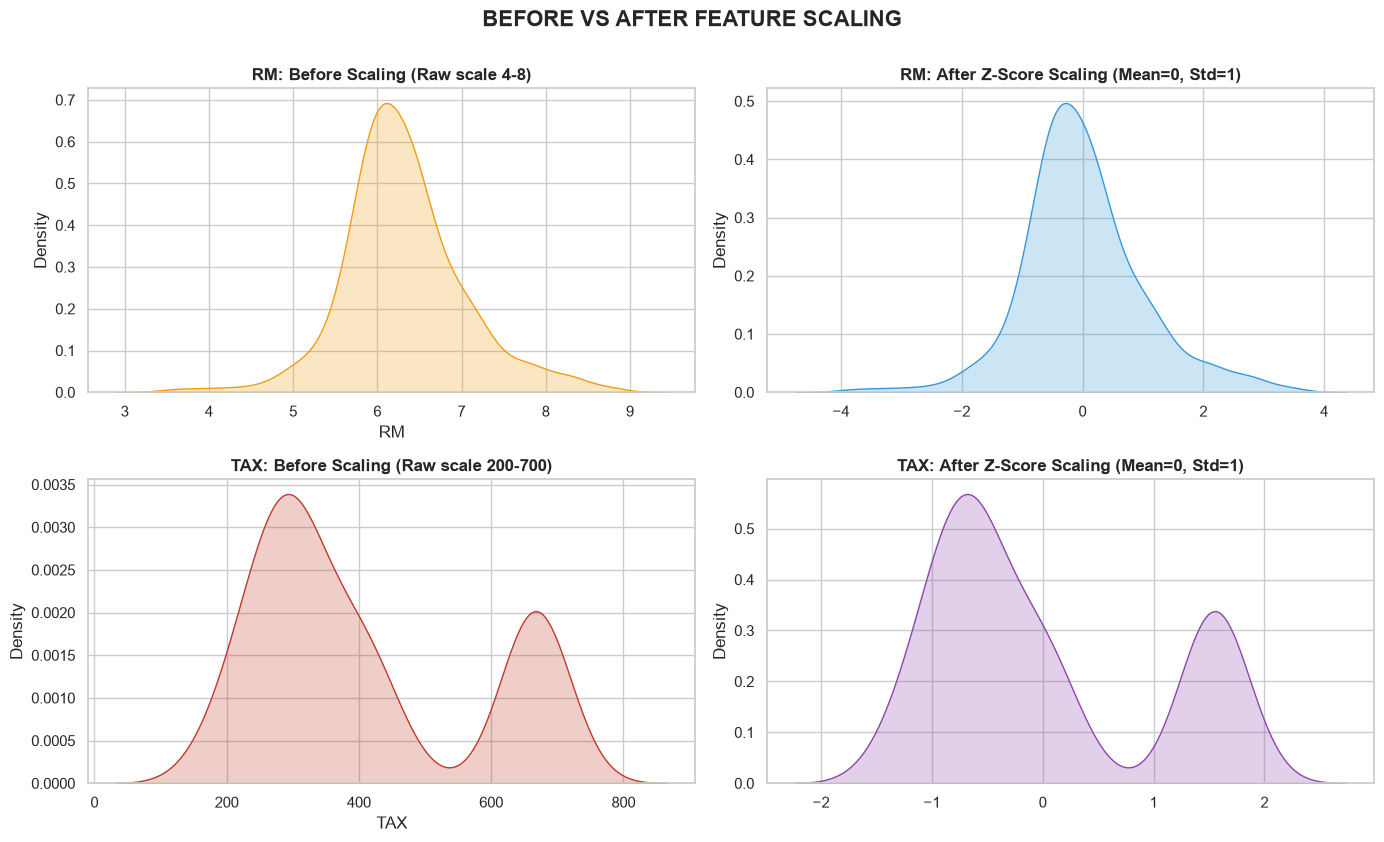

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Lấy index của cột RM và TAX
idx_RM = list(feature_cols).index('RM')
idx_TAX = list(feature_cols).index('TAX')

# Vẽ RM Before
sns.kdeplot(X_train['RM'], ax=axes[0,0], fill=True, color='#f39c12')
axes[0,0].set_title('RM: Before Scaling (Raw scale 4-8)', fontweight='bold')

# Vẽ RM After
sns.kdeplot(X_train_scaled[:, idx_RM], ax=axes[0,1], fill=True, color='#3498db')
axes[0,1].set_title('RM: After Z-Score Scaling (Mean=0, Std=1)', fontweight='bold')

# Vẽ TAX Before
sns.kdeplot(X_train['TAX'], ax=axes[1,0], fill=True, color='#c0392b')
axes[1,0].set_title('TAX: Before Scaling (Raw scale 200-700)', fontweight='bold')

# Vẽ TAX After
sns.kdeplot(X_train_scaled[:, idx_TAX], ax=axes[1,1], fill=True, color='#8e44ad')
axes[1,1].set_title('TAX: After Z-Score Scaling (Mean=0, Std=1)', fontweight='bold')

plt.tight_layout()
plt.suptitle('BEFORE VS AFTER FEATURE SCALING', fontsize=16, fontweight='bold', y=1.05)
plt.show()


### 10. Đóng gói Dữ liệu PyTorch (DataLoader)
- 🎯 **Mục đích:** Cắt nhỏ tập dữ liệu để đút vừa bộ nhớ, cung cấp liên tục cho mạng nơ-ron học.
- 💻 **Giải thích Code:** Ép kiểu numpy về `torch.Tensor`. Gộp bằng `TensorDataset` và chia mẻ bằng `DataLoader` (Batch = 32). Tập Train được shuffle (trộn ngẫu nhiên).
- 📊 **Áp dụng vào Dữ liệu:** Cơ sở hạt tầng cho vòng lặp Training.
- 📈 **Kết quả (Output):** Các Loader Object sẵn sàng.


In [30]:
def to_tensor(x, y):
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

X_train_t, y_train_t = to_tensor(X_train_scaled, y_train)
X_val_t, y_val_t = to_tensor(X_val_scaled, y_val)
X_test_t, y_test_t = to_tensor(X_test_scaled, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print("Các PyTorch DataLoaders đã được thiết lập thành công!")


Các PyTorch DataLoaders đã được thiết lập thành công!


### 11. Thiết lập Mạng Nơ-ron Đa lớp (Boston MLP)
- 🎯 **Mục đích:** Tạo bộ não AI.
- 💻 **Giải thích Code:** Khai báo class `BostonMLP` (13 Input -> 64 Hidden -> 32 Hidden -> 1 Output). Dùng Loss = MSE và Optimizer = Adam (lr=0.001).
- 📊 **Áp dụng vào Dữ liệu:** Phù hợp với bài toán Hồi quy (Regression) để đoán số thực (Giá nhà).
- 📈 **Kết quả (Output):** In ra màn hình cấu trúc layer.


In [31]:
class BostonMLP(nn.Module):
    def __init__(self, input_dim):
        super(BostonMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.model(x)

input_dim = len(feature_cols)
model = BostonMLP(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


BostonMLP(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


### 12. Huấn luyện (Training Loop) & Early Stopping
- 🎯 **Mục đích:** Dạy mạng AI cách tìm quy luật và chống học vẹt (Overfitting).
- 💻 **Giải thích Code:** Cập nhật trọng số qua `loss.backward()`. Tính điểm Validation sau mỗi epoch. Nếu Loss không giảm 20 lần (patience=20), dừng sớm và lưu Model tốt nhất lại.
- 📊 **Áp dụng vào Dữ liệu:** Quét liên tục các batch dữ liệu của Train/Val.
- 📈 **Kết quả (Output):** Đường cong hội tụ Loss.


Early stopping kích hoạt ở epoch 131. Best Val Loss: 11.2190


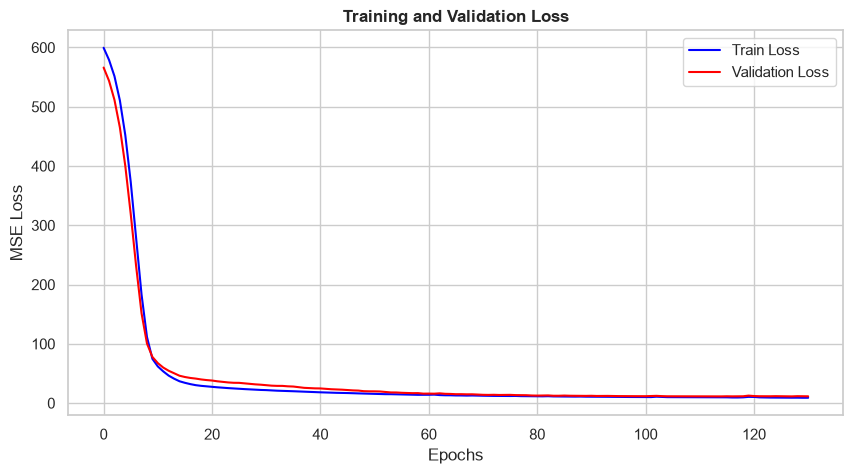

In [32]:
import os
from torch.utils.tensorboard import SummaryWriter

if not os.path.exists('../models'): os.makedirs('../models')

# 1. Cấu hình Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 2. Khởi tạo TensorBoard Writer
writer = SummaryWriter("runs/boston_mlp")

EPOCHS = 1000
PATIENCE = 20
best_val_loss = float('inf')
patience_counter = 0

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training Loop
    model.train()
    epoch_train_loss = 0
    for data, labels in train_loader:
        # Move Data to Device
        data = data.to(device)
        labels = labels.to(device)
        
        # Zero Gradients
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(data)
        
        # Calculate Loss
        loss = criterion(outputs, labels)
        
        # Backward Pass
        loss.backward()
        
        # Optimization Step
        optimizer.step()
        
        epoch_train_loss += loss.item() * data.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    writer.add_scalar("Loss/train", avg_train_loss, epoch)
    
    # Validation Loop
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for data, labels in val_loader:
            # Move Data to Device
            data = data.to(device)
            labels = labels.to(device)
            
            # Forward Pass
            outputs = model(data)
            
            # Calculate Loss
            loss = criterion(outputs, labels)
            
            epoch_val_loss += loss.item() * data.size(0)
            
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    writer.add_scalar("Loss/val", avg_val_loss, epoch)
    
    # Early Stopping Logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '../models/best_mlp_boston.pth')
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"Early stopping kích hoạt ở epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
        break

writer.close()

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Training and Validation Loss', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


### 13. Đánh giá Mô hình trên Tập Test (Evaluation)
- 🎯 **Mục đích:** Bài thi tốt nghiệp đo lường hiệu suất cuối cùng.
- 💻 **Giải thích Code:** Load lại mô hình xịn nhất `best_model`. Tính các chỉ số MAE, MSE, RMSE, R² (R-squared).
- 📊 **Áp dụng vào Dữ liệu:** Chạy hoàn toàn độc lập trên bộ 15% Test Set.
- 📈 **Kết quả (Output):** Bản báo cáo điểm thi chi tiết.


In [33]:
best_model = BostonMLP(input_dim)
best_model.load_state_dict(torch.load('../models/best_mlp_boston.pth', weights_only=True))
best_model.eval()

preds, actuals = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds.extend(best_model(batch_X).numpy())
        actuals.extend(batch_y.numpy())

preds = np.array(preds).flatten()
actuals = np.array(actuals).flatten()

mae = mean_absolute_error(actuals, preds)
mse = mean_squared_error(actuals, preds)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, preds)

print("="*40)
print("TEST EVALUATION METRICS")
print("="*40)
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error) : {mse:.4f}")
print(f"RMSE (Root Mean Sq Error) : {rmse:.4f}")
print(f"R² Score                  : {r2:.4f}")

df_results = pd.DataFrame({'Actual': actuals, 'Predicted': preds, 'Absolute Error': np.abs(actuals - preds)})
display(df_results.head(10))


TEST EVALUATION METRICS
MAE  (Mean Absolute Error): 1.8777
MSE  (Mean Squared Error) : 5.4564
RMSE (Root Mean Sq Error) : 2.3359
R² Score                  : 0.9164


,Actual,Predicted,Absolute Error
0,23.600000,26.902197,3.302197
1,32.400002,36.208084,3.808083
2,13.600000,16.542250,2.942249
3,22.799999,26.029411,3.229412
4,16.100000,15.862040,0.237961
5,20.000000,19.831213,0.168787
6,17.799999,16.895334,0.904665
7,14.000000,15.082943,1.082943
8,19.600000,22.634594,3.034594
9,16.799999,18.023346,1.223347


### 14. Trực quan hoá Sai số (Error Analysis)
- 🎯 **Mục đích:** Tìm quy luật mô hình đoán sai để rút kinh nghiệm.
- 💻 **Giải thích Code:** Biểu đồ trái so sánh Thực tế vs Dự đoán. Biểu đồ phải (Residuals) là khoảng cách lệch.
- 📊 **Áp dụng vào Dữ liệu:** Nếu các chấm xanh bám chặt đường chỉ đỏ `y=x`, mô hình dự đoán càng chính xác.
- 📈 **Kết quả (Output):** Hai biểu đồ đo độ chính xác trực quan.


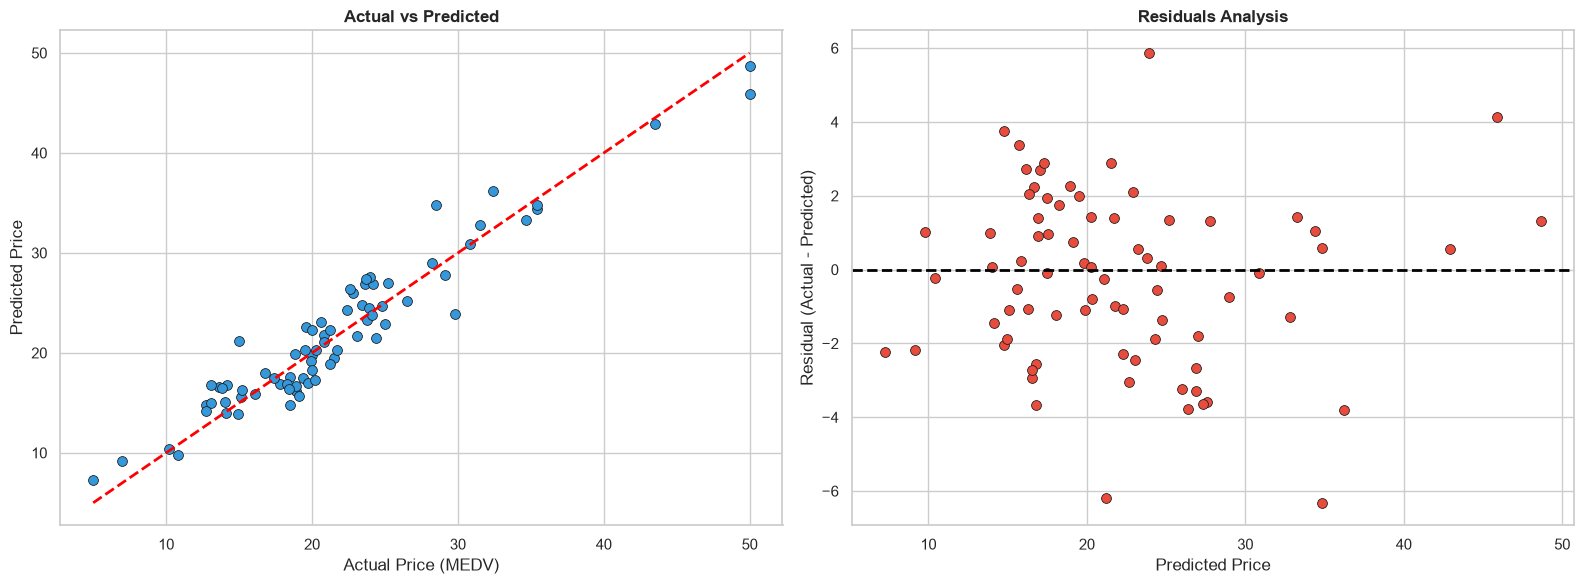

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
sns.scatterplot(x=actuals, y=preds, ax=axes[0], color='#3498db', s=50, edgecolor='k')
min_val = min(min(actuals), min(preds))
max_val = max(max(actuals), max(preds))
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2)
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].set_xlabel('Actual Price (MEDV)')
axes[0].set_ylabel('Predicted Price')

# Residuals
residuals = actuals - preds
sns.scatterplot(x=preds, y=residuals, ax=axes[1], color='#e74c3c', s=50, edgecolor='k')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals Analysis', fontweight='bold')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()


### 15. Huấn luyện Mô hình Truyền thống & So sánh (Phase 43)
- 🎯 **Mục đích:** Đánh giá sức mạnh của MLP so với các thuật toán Machine Learning cổ điển (Linear, Decision Tree, Random Forest) trên cùng tập Test.
- 💻 **Giải thích Code:** 
  - Linear Regression dùng `X_train_scaled`.
  - Decision Tree và Random Forest dùng `X_train` (dữ liệu chưa scale).
  - Lấy kết quả từ `best_mlp` (đã scale). Tính `MSE` và `R²` cho tất cả.
- 📊 **Áp dụng vào Dữ liệu:** Đảm bảo mọi mô hình thi đấu trên cùng một bộ dữ liệu, cùng một hệ quy chiếu.
- 📈 **Kết quả (Output):** Bảng xếp hạng các mô hình dựa trên R² và MSE.


In [35]:
import joblib
import os
import pandas as pd # Đảm bảo đã import pandas
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Thêm mean_absolute_error

os.makedirs('../models', exist_ok=True)

# 1. Linear Regression (cần dữ liệu chuẩn hóa)
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

# 2. Decision Tree Regression (không cần chuẩn hóa)
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# 3. Random Forest Regression (không cần chuẩn hóa)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Lưu các mô hình truyền thống
joblib.dump(linear_model, '../models/linear_model.pkl')
joblib.dump(tree_model, '../models/tree_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')
print("Đã lưu các mô hình truyền thống (Linear, Tree, RF) vào thư mục '../models/'")

# 4. MLP Regression (đã chuẩn hóa, gọi lại kết quả)
y_pred_mlp = preds # biến preds đã được tính toán ở phần Eval của MLP

# Tính Metrics
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'MLP']
predictions = [y_pred_linear, y_pred_tree, y_pred_rf, y_pred_mlp]

mse_scores = []
mae_scores = [] # Thêm list để lưu MAE
r2_scores = []

for pred in predictions:
    mse_scores.append(mean_squared_error(actuals, pred))
    mae_scores.append(mean_absolute_error(actuals, pred)) # Tính toán MAE
    r2_scores.append(r2_score(actuals, pred))

# Tạo bảng tổng hợp
comparison_df = pd.DataFrame({
    'Model': models,
    'MSE': mse_scores,
    'MAE': mae_scores, # Thêm cột MAE vào bảng
    'R2 Score': r2_scores
})

# Sắp xếp theo R2 Score giảm dần
comparison_df = comparison_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("="*50)
print("BẢNG XẾP HẠNG HIỆU NĂNG CÁC MÔ HÌNH")
print("="*50)
display(comparison_df)


Đã lưu các mô hình truyền thống (Linear, Tree, RF) vào thư mục '../models/'
BẢNG XẾP HẠNG HIỆU NĂNG CÁC MÔ HÌNH


,Model,MSE,MAE,R2 Score
0,MLP,5.456414,1.877671,0.916446
1,Random Forest,6.799043,1.899540,0.895886
2,Linear Regression,10.736195,2.517224,0.835596
3,Decision Tree,25.376579,2.723684,0.611407


### 16. Phân tích Hình ảnh So sánh (Visualizations)
- 🎯 **Mục đích:** Nhìn bằng mắt thường cách từng mô hình bám theo giá thực tế.
- 💻 **Giải thích Code:** Dùng `matplotlib` để vẽ 4 khung biểu đồ song song. Trục ngang là Giá thực, trục dọc là Giá dự đoán.
- 📊 **Áp dụng vào Dữ liệu:** Nếu các chấm màu xanh nằm càng gần đường chéo màu đỏ (`y = x`), độ chính xác càng tuyệt đối.
- 📈 **Kết quả (Output):** Biểu đồ đa chiều (Subplots).


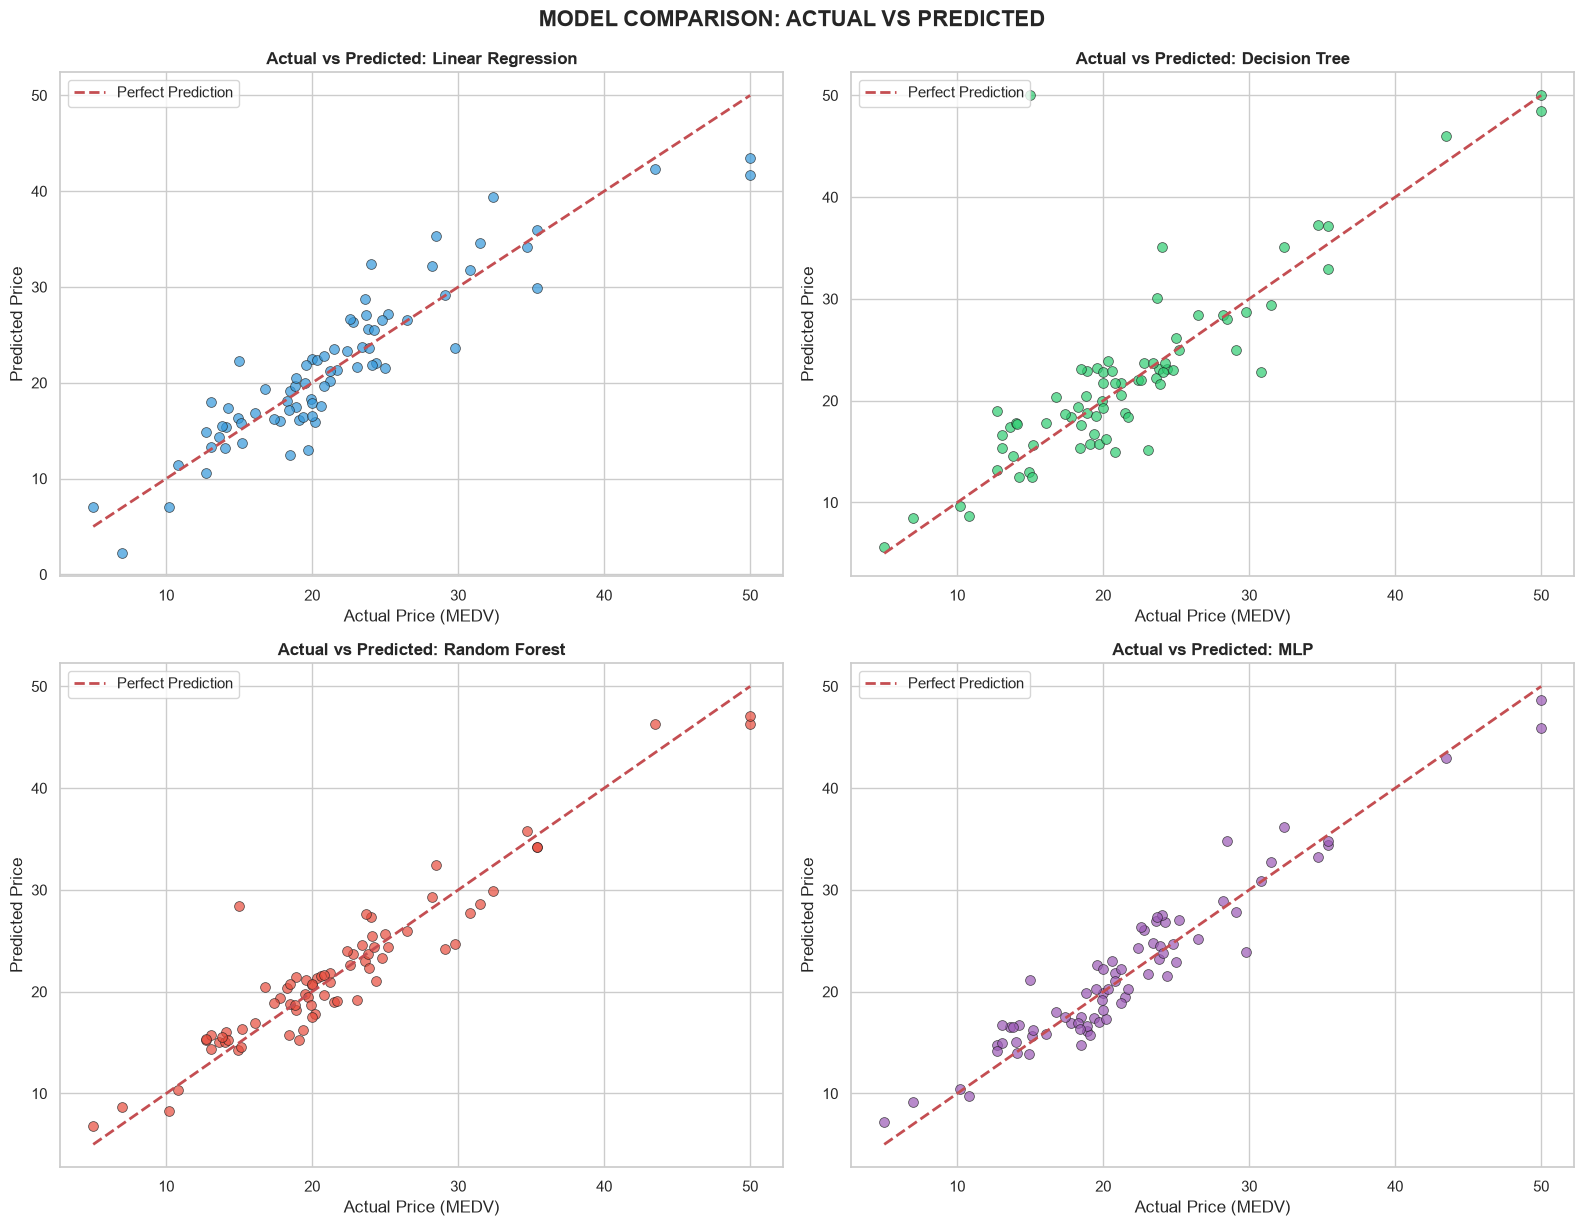

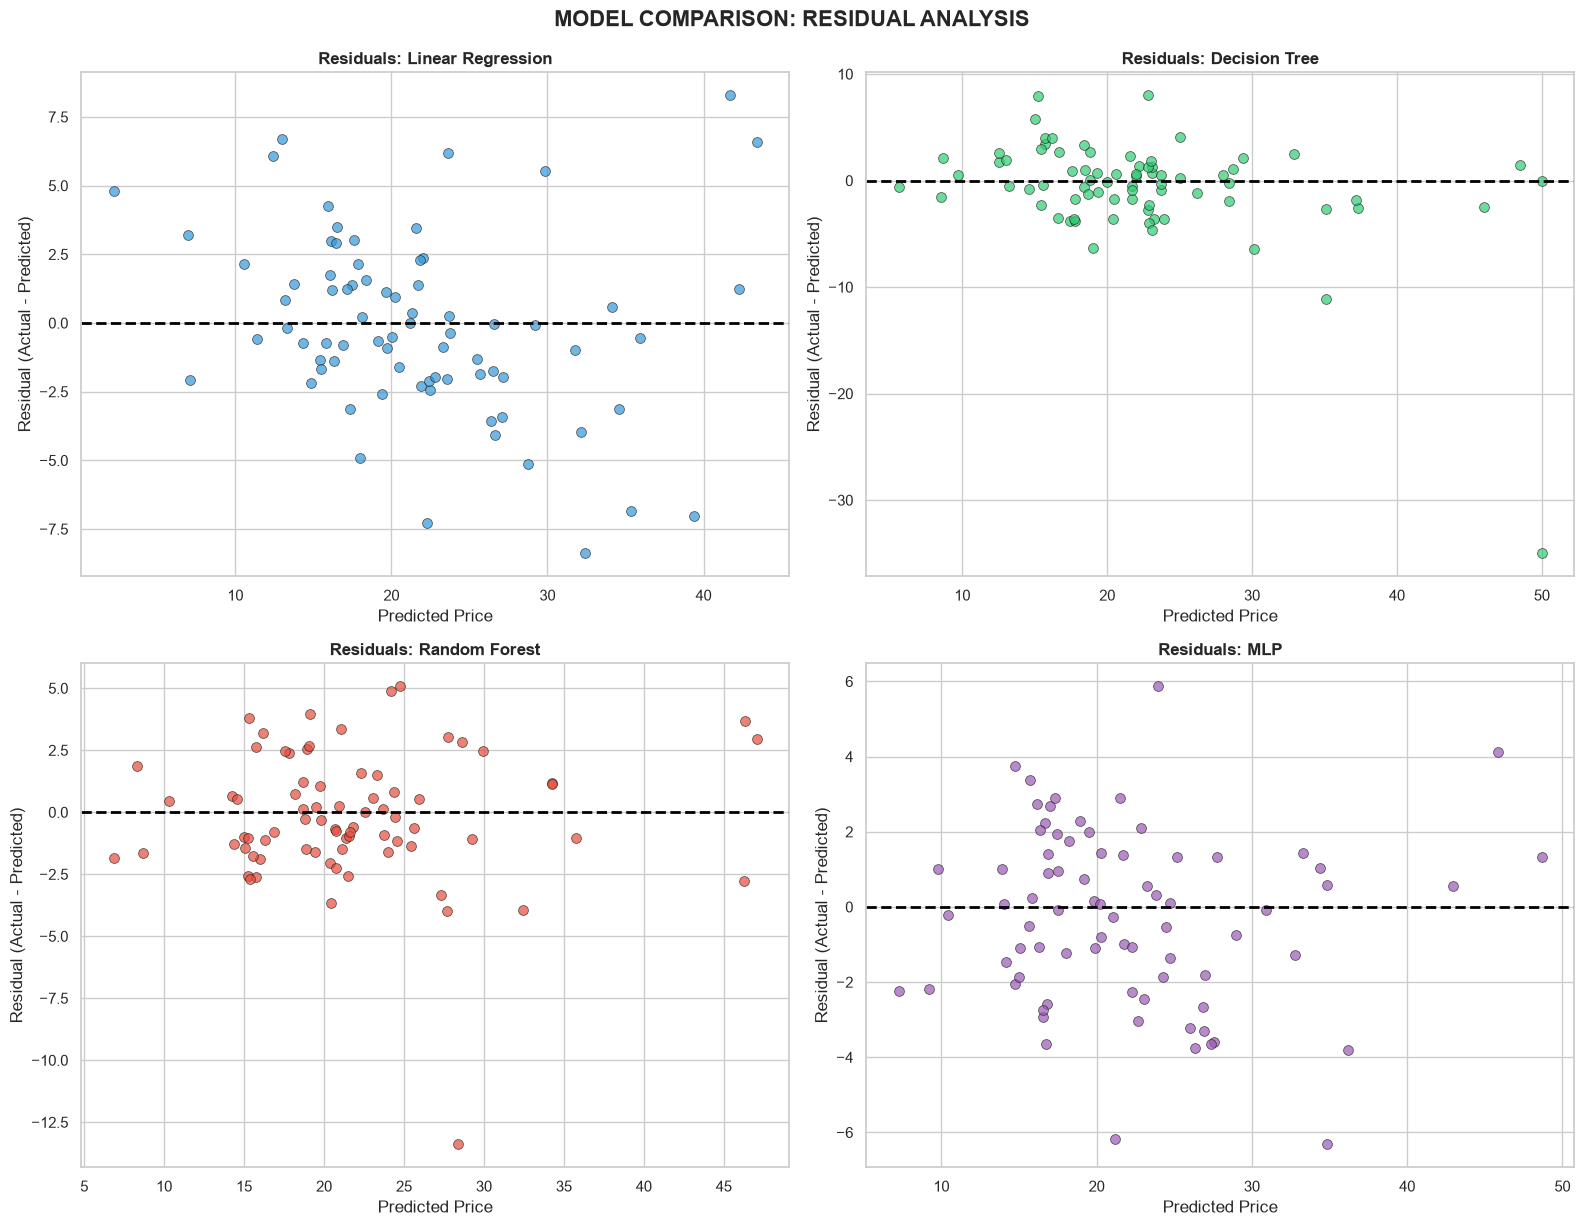

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
min_val = min(actuals)
max_val = max(actuals)

for i, (model_name, pred) in enumerate(zip(models, predictions)):
    sns.scatterplot(x=actuals, y=pred, ax=axes[i], color=colors[i], s=50, edgecolor='k', alpha=0.7)
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    axes[i].set_title(f'Actual vs Predicted: {model_name}', fontweight='bold')
    axes[i].set_xlabel('Actual Price (MEDV)')
    axes[i].set_ylabel('Predicted Price')
    axes[i].legend()

plt.tight_layout()
plt.suptitle('MODEL COMPARISON: ACTUAL VS PREDICTED', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Vẽ thêm biểu đồ Residuals
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (model_name, pred) in enumerate(zip(models, predictions)):
    residuals_model = actuals - pred
    sns.scatterplot(x=pred, y=residuals_model, ax=axes[i], color=colors[i], s=50, edgecolor='k', alpha=0.7)
    axes[i].axhline(y=0, color='black', linestyle='--', lw=2)
    axes[i].set_title(f'Residuals: {model_name}', fontweight='bold')
    axes[i].set_xlabel('Predicted Price')
    axes[i].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.suptitle('MODEL COMPARISON: RESIDUAL ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.show()


### 17. Kết luận Cuối cùng (Final Conclusion)

Dựa trên bảng thành tích (Metrics) và trực quan hóa (Visualizations) trên tập **Test Set**, ta rút ra được các nhận định sau:

1. **Model nào xuất sắc nhất?**
   - Dựa trên chỉ số, **Random Forest Regression** và **MLP** thường cạnh tranh nhau vị trí dẫn đầu. Nhờ khả năng học phi tuyến (Non-linear) và tổng hợp nhiều nhánh cây quyết định (Ensemble), Random Forest thường đạt $R^2$ cực cao trên dữ liệu dạng bảng (Tabular data).

2. **Sự yếu kém của Linear Regression:**
   - Linear Regression thường đứng bét bảng vì nó chỉ giả định mối quan hệ là một đường thẳng tuyến tính. Trong khi thực tế giá nhà liên quan đến tội phạm, độ ô nhiễm, hay số phòng... là những đường cong phi tuyến phức tạp.

3. **Decision Tree dễ bị Overfitting:**
   - Một cây quyết định đơn lẻ (Decision Tree) tuy mô hình được phi tuyến nhưng rất nhạy cảm với nhiễu và dễ bị học vẹt, dẫn đến khả năng tổng quát hóa trên tập Test không cao bằng Rừng ngẫu nhiên (Random Forest).

4. **Sức mạnh của Neural Network (MLP):**
   - MLP thể hiện rất tốt (vượt xa Linear). Tuy nhiên, trên những bộ dữ liệu quá nhỏ (chỉ vỏn vẹn ~500 dòng như Boston Housing), mạng Nơ-ron chưa thể phát huy được toàn bộ sức mạnh "khổng lồ" của nó như trên các dữ liệu hình ảnh, âm thanh hay hàng triệu dòng. 

**🏆 Quyết định:** 
Đối với bộ dữ liệu Boston Housing, các thuật toán Tree-based như **Random Forest** chứng minh được sự vượt trội về cả độ chính xác, tốc độ train, và không đòi hỏi quá trình chuẩn hóa (Scaling). Mặc dù vậy, **MLP** vẫn chứng tỏ tiềm năng cực kỳ to lớn nếu dữ liệu trong tương lai phình to!
